# Import Libraries

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt


# SingleHiddenLayerNN class Implementation

In [3]:
class SingleHiddenLayerNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01, iterations=10000):
        self.lr = learning_rate
        self.iterations = iterations
        self.cost_history = []

        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        # Sigmoid activation function
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)

    def forward(self, X):
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]

        # Output layer gradients
        dz2 = self.a2 - y
        dW2 = (1 / m) * np.dot(self.a1.T, dz2)
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)

        # Hidden layer gradients
        dz1 = np.dot(dz2, self.W2.T) * self.sigmoid_derivative(self.z1)
        dW1 = (1 / m) * np.dot(X.T, dz1)
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def cost(self, y_pred, y_true):
        # Cross-entropy loss
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        y = y.reshape(-1, 1)

        # Gradient descent
        for i in range(self.iterations):
            y_pred = self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)

            # Update parameters
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

            self.cost_history.append(self.cost(y_pred, y))

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)


# Prepare Data

In [4]:
# Generate non-linearly separable data (two moons)
np.random.seed(42)
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Train the Model

In [5]:
# Initialize and fit model
model = SingleHiddenLayerNN(input_size=2, hidden_size=8, output_size=1, learning_rate=0.5, iterations=5000)
model.fit(X_train, y_train)


# Evaluate the Model

In [6]:
# Evaluate the model
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred.flatten() == y_test)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.88


# Visualize Results

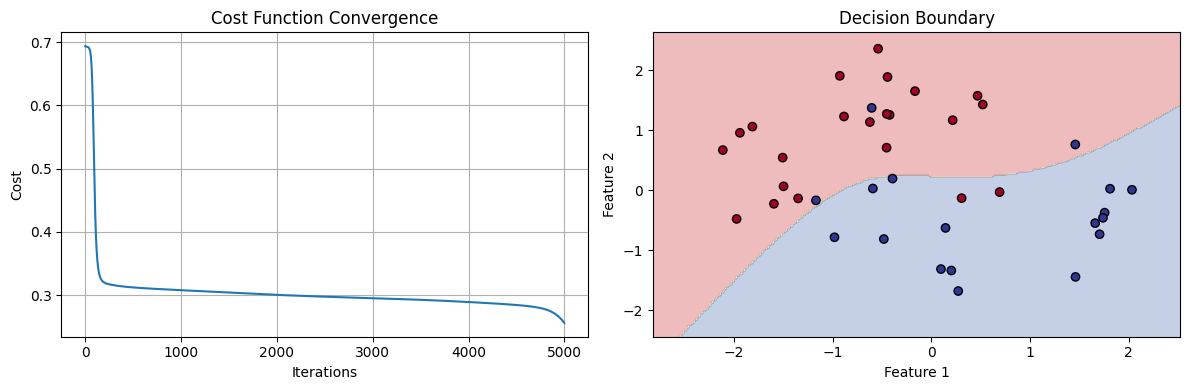

In [7]:
# Plot cost convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.cost_history)
axes[0].set_title('Cost Function Convergence')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost')
axes[0].grid(True)

# Plot decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5, 200),
    np.linspace(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='RdYlBu')
axes[1].set_title('Decision Boundary')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()
